
# Project : Salary Predictor with Explainable AI

Predict salary for data and AI jobs and explain every prediction with SHAP, partial dependence and a plain-English explanation.

## What this notebook does
- Makes 4000 job salary records (or uses your salary_data.csv with the same column names)
- Compares Linear Regression, Random Forest and Gradient Boosting
- Explains the best model globally with SHAP (which features matter most)
- Explains single predictions in plain words, with a prediction range (10th to 90th percentile)
- Shows partial dependence (how salary changes with experience)
- Has a what-if function to test different profiles
- Checks the model's errors by group (remote, city tier, education)

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn shap

## Step 2: Load the data
Salary is in LPA (lakhs per year). Sample data is made up for practice.

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(8)
sns.set_style("whitegrid")

def make_salary_data(n=4000):
    titles = ["Data Analyst", "Data Scientist", "ML Engineer", "Data Engineer", "BI Developer", "AI Engineer"]
    title_base = {"Data Analyst": 5, "Data Scientist": 9, "ML Engineer": 11, "Data Engineer": 10, "BI Developer": 6.5, "AI Engineer": 12}
    edu_bonus = {"Bachelors": 0, "Masters": 1.5, "PhD": 4}
    city_mult = {"Tier1": 1.2, "Tier2": 1.0, "Tier3": 0.85}
    size_mult = {"Startup": 0.95, "Mid": 1.0, "Large": 1.15}
    rows = []
    for i in range(n):
        title = np.random.choice(titles)
        exp = round(float(np.clip(np.random.gamma(2.2, 2.0), 0, 20)), 1)
        edu = np.random.choice(["Bachelors", "Masters", "PhD"], p=[0.6, 0.35, 0.05])
        city = np.random.choice(["Tier1", "Tier2", "Tier3"], p=[0.5, 0.3, 0.2])
        size = np.random.choice(["Startup", "Mid", "Large"], p=[0.3, 0.4, 0.3])
        skills = int(np.random.randint(2, 12))
        remote = int(np.random.rand() < 0.3)
        certs = int(np.random.randint(0, 5))
        salary = (title_base[title] + edu_bonus[edu]) * city_mult[city] * size_mult[size]
        salary = salary * (1 + 0.09 * exp - 0.0025 * exp * exp) + skills * 0.25 + certs * 0.3 + remote * 0.5
        salary = salary * np.random.normal(1, 0.07)
        rows.append({"job_title": title, "experience_years": exp, "education": edu, "city_tier": city, "company_size": size,
                     "skills_count": skills, "remote": remote, "certifications": certs, "salary_lpa": round(salary, 2)})
    return pd.DataFrame(rows)

if os.path.exists("salary_data.csv"):
    df = pd.read_csv("salary_data.csv")
    print("Using your salary_data.csv")
else:
    df = make_salary_data()
    print("Using made-up sample data")

print(df.shape)
df.head()

Using made-up sample data
(4000, 9)


,job_title,experience_years,education,city_tier,company_size,skills_count,remote,certifications,salary_lpa
0,Data Engineer,7.9,Masters,Tier2,Mid,11,1,2,21.05
1,Data Engineer,6.5,Bachelors,Tier3,Mid,11,1,1,17.79
2,AI Engineer,1.8,Bachelors,Tier3,Mid,7,1,4,14.61
3,ML Engineer,11.6,Bachelors,Tier1,Mid,8,0,3,26.91
4,ML Engineer,5.0,Masters,Tier1,Mid,4,1,1,21.34


## Step 3: Quick look at the data

0 missing values
count    4000.00
mean       16.49
std         5.09
min         4.66
25%        12.71
50%        16.09
75%        19.76
max        37.31
Name: salary_lpa, dtype: float64


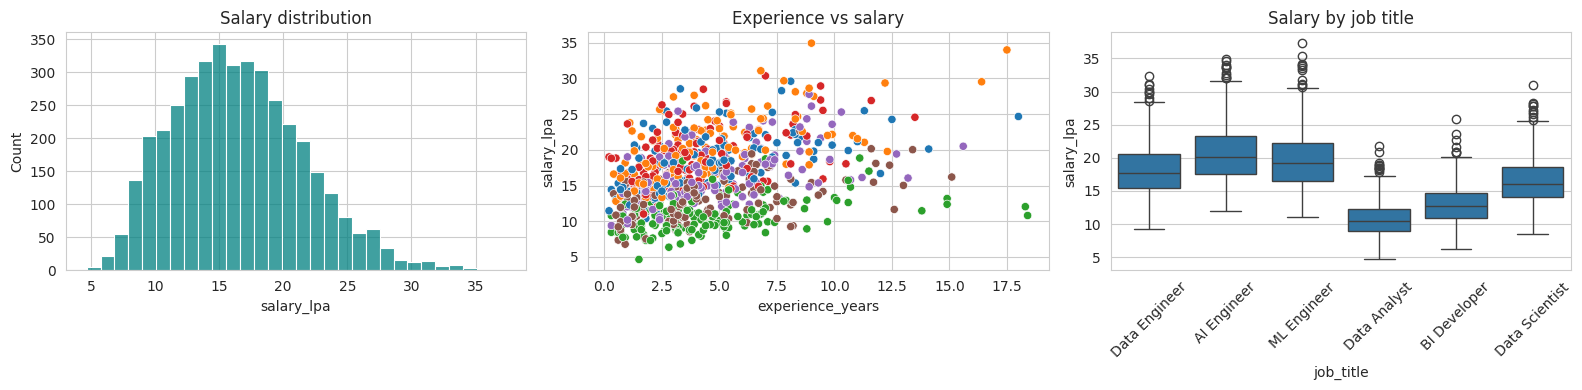

In [3]:
print(df.isna().sum().sum(), "missing values")
print(df["salary_lpa"].describe().round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["salary_lpa"], bins=30, ax=ax[0], color="teal")
ax[0].set_title("Salary distribution")
sns.scatterplot(data=df.sample(800, random_state=1), x="experience_years", y="salary_lpa", hue="job_title", ax=ax[1], legend=False)
ax[1].set_title("Experience vs salary")
sns.boxplot(data=df, x="job_title", y="salary_lpa", ax=ax[2])
ax[2].tick_params(axis="x", rotation=45)
ax[2].set_title("Salary by job title")
plt.tight_layout()
plt.show()

## Step 4: Train and compare models

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = pd.get_dummies(df.drop(columns=["salary_lpa"]), drop_first=False)
y = df["salary_lpa"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=3, random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rows.append({"model": name, "MAE_lpa": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)})
results = pd.DataFrame(rows).sort_values("MAE_lpa")
print(results.round(3))

best_name = results.iloc[0]["model"]
print("\nBest model:", best_name)

tree_models = {k: v for k, v in models.items() if k != "Linear Regression"}
explain_name = results[results["model"].isin(tree_models.keys())].iloc[0]["model"]
model = models[explain_name]
print("Model used for SHAP explanations:", explain_name)

               model  MAE_lpa     R2
2  Gradient Boosting    0.984  0.933
0  Linear Regression    1.131  0.915
1      Random Forest    1.225  0.901

Best model: Gradient Boosting
Model used for SHAP explanations: Gradient Boosting


## Step 4b: Prediction ranges
A single number looks too sure of itself. Two extra models predict the 10th and 90th percentile, so we can give a range. About 80% of real salaries in the test set should land inside it.

In [5]:
q_low = GradientBoostingRegressor(loss="quantile", alpha=0.1, n_estimators=250, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train, y_train)
q_high = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=250, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train, y_train)
inside = (y_test >= q_low.predict(X_test)) & (y_test <= q_high.predict(X_test))
print("Share of test salaries inside the predicted range:", round(inside.mean() * 100, 1), "% (target about 80%)")
print("The range is a bit narrower than promised if this is below 80%, so treat it as a rough guide.")
print("Average width of the range:", round((q_high.predict(X_test) - q_low.predict(X_test)).mean(), 2), "LPA")
print("\nNote: the data is made up and follows a clean formula, so R2 and these ranges look better than they would on real, noisier salary data.")

Share of test salaries inside the predicted range: 74.9 % (target about 80%)
The range is a bit narrower than promised if this is below 80%, so treat it as a rough guide.
Average width of the range: 3.28 LPA

Note: the data is made up and follows a clean formula, so R2 and these ranges look better than they would on real, noisier salary data.


## Step 5: Global explanation with SHAP
One-hot encoding splits `job_title` into many yes/no columns, which makes explanations confusing (for example 'Bachelors = False adds LPA'). So the SHAP values of all columns that come from the same original feature are added together. Then we can say 'job title adds 2.5 LPA' in plain words.

Average predicted salary (base value): 16.54 LPA

Average impact on salary by original feature (LPA):
job_title           3.00
city_tier           1.57
experience_years    1.49
education           1.26
company_size        0.86
skills_count        0.58
certifications      0.30
remote              0.16
dtype: float64


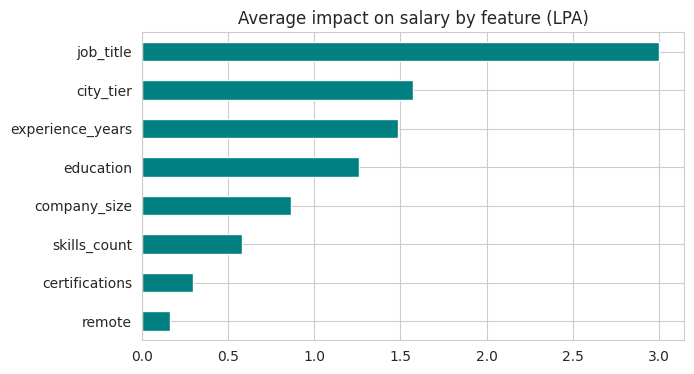

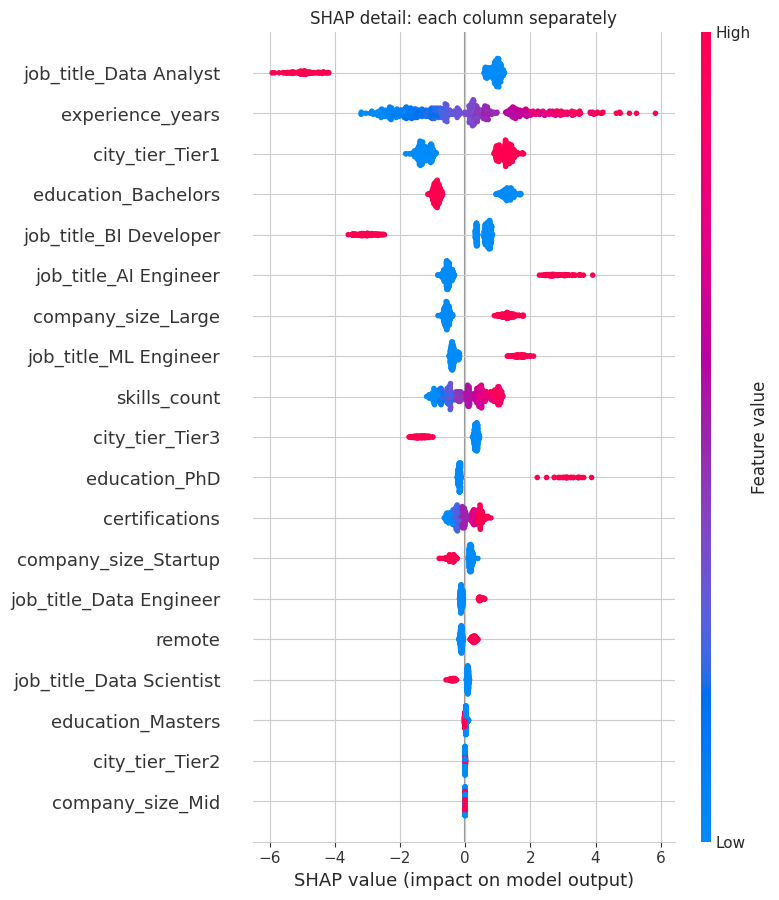

In [6]:
import shap

X_sample = X_test.sample(500, random_state=1)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
base_value = float(np.ravel(explainer.expected_value)[0])
print("Average predicted salary (base value):", round(base_value, 2), "LPA")

orig_cols = ["job_title", "experience_years", "education", "city_tier", "company_size", "skills_count", "remote", "certifications"]

def base_name(col):
    for o in orig_cols:
        if col == o or col.startswith(o + "_"):
            return o
    return col

group_of = [base_name(c) for c in X_sample.columns]

def group_shap(values):
    table = pd.DataFrame(values, columns=X_sample.columns)
    return table.T.groupby(group_of).sum().T

shap_grouped = group_shap(shap_values)
mean_abs_grouped = shap_grouped.abs().mean().sort_values(ascending=False)
print("\nAverage impact on salary by original feature (LPA):")
print(mean_abs_grouped.round(2))

mean_abs_grouped.sort_values().plot(kind="barh", figsize=(7, 4), color="teal")
plt.title("Average impact on salary by feature (LPA)")
plt.show()

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP detail: each column separately")
plt.tight_layout()
plt.show()

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).sort_values(ascending=False)

## Step 6: Explain one prediction in plain words

Predicted salary: 16.24 LPA (average is 16.54 )
 - job_title = AI Engineer adds 3.81 LPA
 - city_tier = Tier3 reduces 2.79 LPA
 - experience_years = 2.0 reduces 1.87 LPA
 - education = Masters adds 0.91 LPA
 - certifications = 0 reduces 0.5 LPA


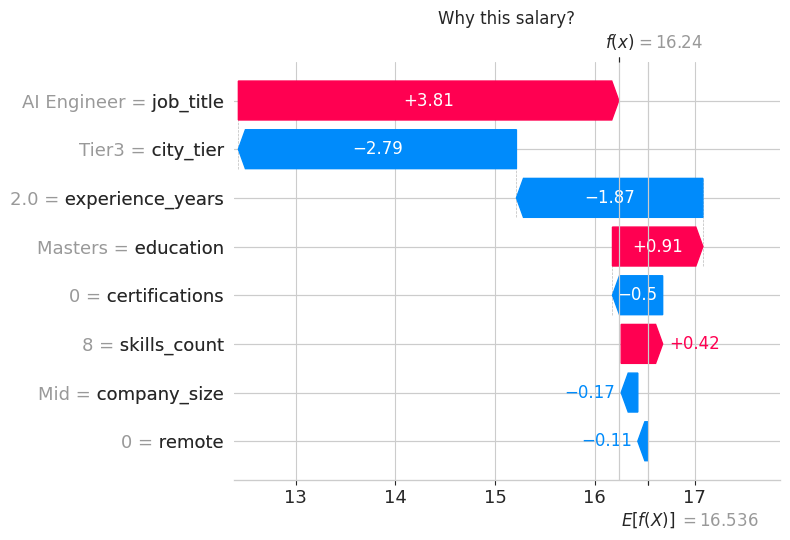

In [7]:
def readable_value(row, group):
    cols = [c for c in X_sample.columns if base_name(c) == group]
    if len(cols) == 1 and cols[0] == group:
        return row[group].values[0]
    for c in cols:
        if row[c].values[0] in (1, True):
            return c[len(group) + 1:]
    return "?"

def explain_person(index_in_sample):
    row = X_sample.iloc[[index_in_sample]]
    sv = explainer.shap_values(row)[0]
    pred = float(model.predict(row)[0])
    contrib = group_shap(np.array([sv])).iloc[0]
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)
    print("Predicted salary:", round(pred, 2), "LPA (average is", round(base_value, 2), ")")
    for feat, val in top.items():
        direction = "adds" if val > 0 else "reduces"
        print(" -", feat, "=", readable_value(row, feat), direction, round(abs(val), 2), "LPA")
    return contrib, pred

contrib0, pred0 = explain_person(0)

exp_obj = shap.Explanation(values=contrib0.values, base_values=base_value, data=np.array([str(readable_value(X_sample.iloc[[0]], g)) for g in contrib0.index]), feature_names=list(contrib0.index))
shap.plots.waterfall(exp_obj, max_display=10, show=False)
plt.title("Why this salary?")
plt.tight_layout()
plt.show()

## Step 7: Partial dependence (how salary changes with one feature)

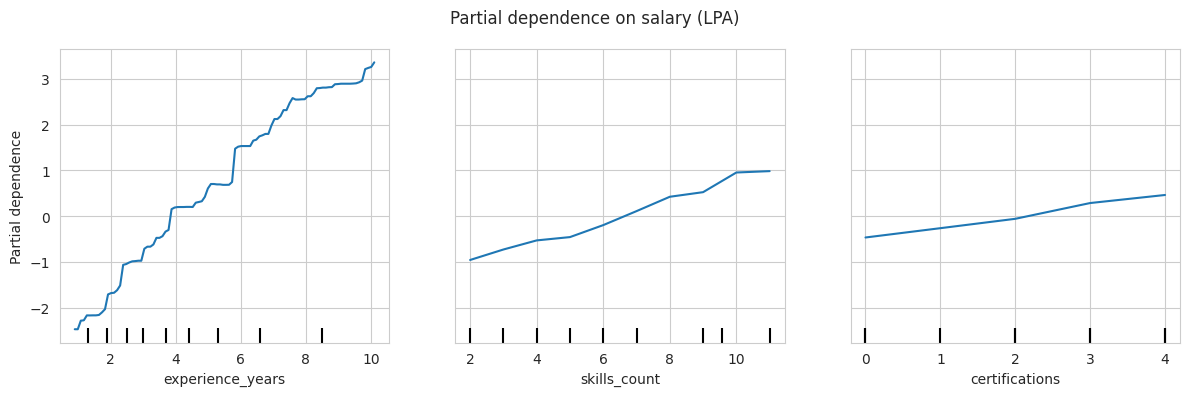

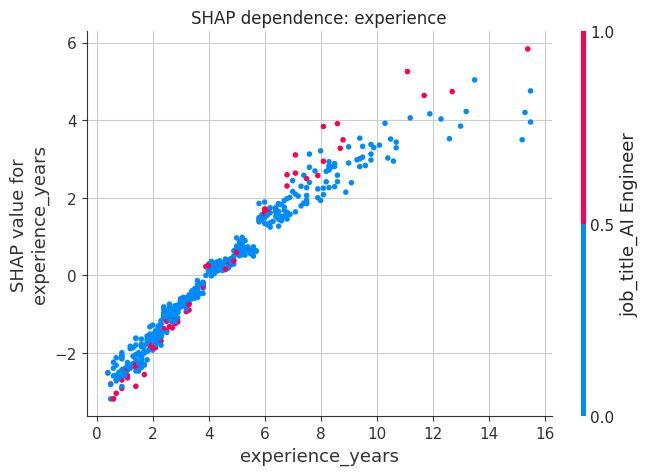

In [8]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(model, X_train, ["experience_years", "skills_count", "certifications"], ax=ax)
plt.suptitle("Partial dependence on salary (LPA)")
plt.tight_layout()
plt.show()

shap.dependence_plot("experience_years", shap_values, X_sample, show=False)
plt.title("SHAP dependence: experience")
plt.show()

## Step 8: What-if predictor (with a range)

In [9]:
def predict_salary(job_title, experience_years, education, city_tier, company_size, skills_count, remote, certifications):
    row = pd.DataFrame([{"job_title": job_title, "experience_years": experience_years, "education": education, "city_tier": city_tier,
                         "company_size": company_size, "skills_count": skills_count, "remote": remote, "certifications": certifications}])
    row = pd.get_dummies(row).reindex(columns=X.columns, fill_value=0)
    pred = float(model.predict(row)[0])
    low = float(q_low.predict(row)[0])
    high = float(q_high.predict(row)[0])
    low = min(low, pred)
    high = max(high, pred)
    sv = explainer.shap_values(row)[0]
    contrib = group_shap_full(np.array([sv]), row.columns).iloc[0]
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(3)
    reasons = []
    for feat, val in top.items():
        reasons.append(feat + (" adds " if val > 0 else " reduces ") + str(round(abs(val), 2)) + " LPA")
    warning = ""
    if experience_years > 20 or experience_years < 0:
        warning = "experience outside the range the model learned (0 to 20 years), do not trust this"
    return round(pred, 2), (round(low, 2), round(high, 2)), reasons, warning

def group_shap_full(values, columns):
    table = pd.DataFrame(values, columns=columns)
    return table.T.groupby([base_name(c) for c in columns]).sum().T

fresher = predict_salary("Data Analyst", 0, "Bachelors", "Tier2", "Mid", 6, 0, 2)
print("Fresher Data Analyst:", fresher)
print("Same person with 2 more certifications and 4 more skills:", predict_salary("Data Analyst", 0, "Bachelors", "Tier2", "Mid", 10, 0, 4))
print("Same person moving to a Tier1 city:", predict_salary("Data Analyst", 0, "Bachelors", "Tier1", "Mid", 6, 0, 2))
scientist = predict_salary("Data Scientist", 3, "Masters", "Tier1", "Large", 8, 0, 3)
print("Data Scientist, 3 years, Masters:", scientist)
print("AI Engineer, 5 years, Masters, remote:", predict_salary("AI Engineer", 5, "Masters", "Tier1", "Large", 9, 1, 3))
print("Analyst with 30 years (outside training range):", predict_salary("Data Analyst", 30, "Bachelors", "Tier2", "Mid", 6, 0, 2))

Fresher Data Analyst: (6.75, (6.75, 7.26), ['job_title reduces 4.93 LPA', 'experience_years reduces 2.45 LPA', 'education reduces 0.97 LPA'], '')
Same person with 2 more certifications and 4 more skills: (8.96, (8.33, 9.99), ['job_title reduces 4.87 LPA', 'experience_years reduces 2.33 LPA', 'skills_count adds 1.08 LPA'], '')
Same person moving to a Tier1 city: (7.61, (7.61, 9.5), ['job_title reduces 5.45 LPA', 'experience_years reduces 2.58 LPA', 'city_tier adds 1.07 LPA'], '')
Data Scientist, 3 years, Masters: (21.3, (19.09, 23.43), ['company_size adds 1.66 LPA', 'city_tier adds 1.64 LPA', 'education adds 1.23 LPA'], '')
AI Engineer, 5 years, Masters, remote: (26.51, (23.23, 28.27), ['job_title adds 4.3 LPA', 'city_tier adds 1.83 LPA', 'company_size adds 1.51 LPA'], '')
Analyst with 30 years (outside training range): (14.59, (10.61, 17.96), ['experience_years adds 6.1 LPA', 'job_title reduces 5.8 LPA', 'education reduces 1.01 LPA'], 'experience outside the range the model learned (0 

## Step 9: Error check by group
A good model should not have much larger errors for one group. We compare the average error by group. (This data has no protected attributes like gender, so this is an error check, not a full fairness audit.)

In [10]:
check = X_test.copy()
check["actual"] = y_test.values
check["pred"] = model.predict(X_test)
check["error"] = check["pred"] - check["actual"]

remote_gap = check.groupby("remote")["error"].agg(["mean", "count"]).round(3)
print("Average prediction error by remote flag (positive = model overpays):")
print(remote_gap)

rows = []
for col in ["city_tier_Tier1", "city_tier_Tier2", "city_tier_Tier3", "education_Bachelors", "education_Masters", "education_PhD"]:
    sub = check[check[col] == 1]
    rows.append({"group": col, "people": len(sub), "average_error": round(sub["error"].mean(), 3), "MAE": round(sub["error"].abs().mean(), 3)})
group_errors = pd.DataFrame(rows)
print(group_errors.to_string(index=False))
worst_gap = group_errors["average_error"].abs().max()
print("\nLargest average error for any group:", round(worst_gap, 2), "LPA. Small groups (like PhD) have noisy numbers.")

Average prediction error by remote flag (positive = model overpays):
         mean  count
remote              
0       0.196    552
1      -0.070    248
              group  people  average_error   MAE
    city_tier_Tier1     396         -0.035 1.084
    city_tier_Tier2     261          0.215 0.908
    city_tier_Tier3     143          0.342 0.843
education_Bachelors     484          0.088 0.921
  education_Masters     270          0.217 1.051
      education_PhD      46         -0.223 1.251

Largest average error for any group: 0.34 LPA. Small groups (like PhD) have noisy numbers.


## Step 10: Key insights and export

In [11]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Best model by MAE:", best_name, "- MAE", round(results.iloc[0]["MAE_lpa"], 2), "LPA, R2", round(results.iloc[0]["R2"], 3), "(made-up data, so real data would be noisier)")
print("2. Most important feature (SHAP, grouped):", mean_abs_grouped.index[0], "-", round(mean_abs_grouped.iloc[0], 2), "LPA on average")
print("3. Top 3 features:", mean_abs_grouped.head(3).index.tolist())
print("4. Prediction range covers", round(inside.mean() * 100, 1), "% of test salaries (target about 80%)")
print("5. Fresher analyst:", fresher[0], "LPA (range", fresher[1], ") vs data scientist with 3 years:", scientist[0], "LPA (range", scientist[1], ")")

importance_table = mean_abs_grouped.reset_index()
importance_table.columns = ["feature", "mean_abs_shap_lpa"]
importance_table.to_csv("salary_shap_importance.csv", index=False)
results.to_csv("salary_model_comparison.csv", index=False)
check.to_csv("salary_test_predictions.csv", index=False)
print("\nSaved salary_shap_importance.csv, salary_model_comparison.csv, salary_test_predictions.csv")

KEY INSIGHTS (calculated from this run)
1. Best model by MAE: Gradient Boosting - MAE 0.98 LPA, R2 0.933 (made-up data, so real data would be noisier)
2. Most important feature (SHAP, grouped): job_title - 3.0 LPA on average
3. Top 3 features: ['job_title', 'city_tier', 'experience_years']
4. Prediction range covers 74.9 % of test salaries (target about 80%)
5. Fresher analyst: 6.75 LPA (range (6.75, 7.26) ) vs data scientist with 3 years: 21.3 LPA (range (19.09, 23.43) )

Saved salary_shap_importance.csv, salary_model_comparison.csv, salary_test_predictions.csv



Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)